In [38]:
import os
import numpy as np
import pandas as pd
import pickle
import re
from aSPA import compute_aSPA_per_country

In [39]:
def get_preds_RF(model_name='RF_results'):
    results_path = rf"D:\results\{model_name}\RF_forecasts"

    all_files = [f for f in os.listdir(results_path) if f.endswith(".pkl")]

    horizon_dict = {}

    for f in all_files:
        if not f.endswith(".pkl"):
            continue

        match = re.match(r"RF_forecast_h(\d+)_(.*)\.pkl", f)
        if not match:
            continue

        horizon = int(match.group(1))
        country = match.group(2)

        with open(os.path.join(results_path, f), "rb") as fh:
            pickle_dict = pickle.load(fh)
        fc_list = pickle_dict["forecast"]
        fc_df = pd.DataFrame(fc_list, columns=["timestamp", "forecast"]).set_index("timestamp")
        fc_df["country"] = country

        horizon_dict.setdefault(horizon, []).append(fc_df)

    # combine countries for each horizon
    horizon_dfs = {
        h: pd.concat(dfs).pivot(columns="country", values="forecast")
        for h, dfs in horizon_dict.items()
    }
    return horizon_dfs


def get_preds_RF_recursive(model_name='RF_recursive_results'):
    results_path = rf"D:\results\{model_name}\RF_forecasts"

    all_files = [f for f in os.listdir(results_path) if f.endswith(".pkl")]
    horizon_dict = {}

    for f in all_files:
        country = re.sub(r"\.pkl$", "", f).replace("RF_forecast_", "")
        with open(os.path.join(results_path, f), "rb") as fh:
            pickle_dict = pickle.load(fh)

        # Now forecast list has horizon included
        fc_list = pickle_dict["forecast"]  # [(timestamp, forecast, horizon), ...]
        fc_df = pd.DataFrame(fc_list, columns=["timestamp", "forecast", "horizon"])
        fc_df["country"] = country

        # split by horizon
        for h, h_df in fc_df.groupby("horizon"):
            df = h_df[["timestamp", "forecast", "country"]].set_index("timestamp")
            horizon_dict.setdefault(h, []).append(df)

    # combine countries for each horizon
    horizon_dfs = {
        h: pd.concat(dfs).pivot(columns="country", values="forecast")
        for h, dfs in horizon_dict.items()
    }
    return horizon_dfs

def get_preds(model_name='Informer_h12_results'):
    results_path = rf"D:\results\{model_name}\results"

    res_folders = os.listdir(results_path)
    sorted_res_folders = sorted(res_folders, key=lambda x: int(x.split('_')[0]))

    horizon_dict = {}

    for folder in sorted_res_folders:
        folder_path = os.path.join(results_path, folder)
        pred_path = os.path.join(folder_path, "prediction.pkl")
        
        with open(pred_path, "rb") as f:
            data_dict = pickle.load(f)

        preds = data_dict['predictions']  # shape: (steps, horizons, features)
        timestamps = pd.to_datetime(data_dict['timestamps'])
        cols = data_dict["columns"]

        n_steps, n_horizons, _ = preds.shape

        for step in range(n_steps):
            origin = timestamps[step]
            for h in range(n_horizons):
                target_time = origin + pd.offsets.MonthEnd(h+1)  # adjust if monthly, or use Day/other freq
                pred_h = preds[step, h, :].reshape(1, -1)
                pred_df = pd.DataFrame(pred_h, columns=cols, index=[target_time])
                pred_df = pred_df.drop("Global Factor", axis = 1)
                horizon_dict.setdefault(h+1, []).append(pred_df)

    # concatenate all steps for each horizon
    horizon_dfs = {h: pd.concat(dfs).sort_index() for h, dfs in horizon_dict.items()}

    return horizon_dfs

transformer_models = ['Autoformer_h1_results',
 'Autoformer_h6_results',
 'Autoformer_h12_results',
 'FEDFormer_h1_results',
 'FEDFormer_h6_results',
 'FEDFormer_h12_results',
 'Informer_h1_results',
 'Informer_h6_results',
 'Informer_h12_results']

res_dict = {}
for model in transformer_models:
    res_dict[model] = get_preds(model)

res_dict["RF"] = get_preds_RF('RF_results')


In [40]:
from darts import TimeSeries
def rows_from_multistep_timeseries(ts_container):
    """
    Works with list or dict of multi-step forecasts.
    Returns {h: DataFrame}, where h = horizon step (1-based).
    Each DataFrame has a DateTimeIndex corresponding to that horizon.
    """
    # normalize input
    if isinstance(ts_container, dict):
        items = ts_container.items()
    else:
        items = enumerate(ts_container)

    # determine horizon length
    first_key, first_ts = next(iter(items))
    if isinstance(first_ts, TimeSeries):
        horizon_len = len(first_ts)
    else:
        horizon_len = len(pd.DataFrame(first_ts))

    # reset iterator
    if isinstance(ts_container, dict):
        items = ts_container.items()
    else:
        items = enumerate(ts_container)

    horizon_dict = {h + 1: {} for h in range(horizon_len)}

    for key, ts in items:
        if isinstance(ts, TimeSeries):
            df = ts.pd_dataframe()  # keeps datetime index
        else:
            df = pd.DataFrame(ts)

        if len(df) == 0:
            continue

        for h in range(horizon_len):
            row = df.iloc[h]
            horizon_dict[h + 1][row.name] = row.to_dict()  # row.name is the timestamp

    # convert each horizon dict into a DataFrame
    for h in horizon_dict:
        horizon_dict[h] = pd.DataFrame.from_dict(horizon_dict[h], orient="index")
        horizon_dict[h].index = pd.to_datetime(horizon_dict[h].index)  # enforce datetime

    return horizon_dict

with open(r"dlinear_forecasts/dlinear_forecast_h1.pkl", "rb") as f:
    dlinear_h1 = pickle.load(f)
    dlinear_h1 = dlinear_h1["forecast"]


with open(r"dlinear_forecasts/dlinear_forecast_h6.pkl", "rb") as f:
    dlinear_h6 = pickle.load(f)
    dlinear_h6 = dlinear_h6["forecast"]

with open(r"dlinear_forecasts/dlinear_forecast_h12.pkl", "rb") as f:
    dlinear_h12_dict = pickle.load(f)
    dlinear_h12 = dlinear_h12_dict["forecast"]

with open(r"nlinear_forecasts/nlinear_forecast_h1.pkl", "rb") as f:
    nlinear_h1 = pickle.load(f)
    nlinear_h1 = nlinear_h1["forecast"]


with open(r"nlinear_forecasts/nlinear_forecast_h6.pkl", "rb") as f:
    nlinear_h6 = pickle.load(f)
    nlinear_h6 = nlinear_h6["forecast"]

with open(r"nlinear_forecasts/nlinear_forecast_h12.pkl", "rb") as f:
    nlinear_h12 = pickle.load(f)
    nlinear_h12 = nlinear_h12["forecast"]

with open(r"nlinear_forecasts_recursive/nlinear_forecast_h12.pkl", "rb") as f:
    nlinear_h12_rec = pickle.load(f)
    nlinear_h12_rec = nlinear_h12_rec["forecast"]

with open(r"dlinear_forecasts_recursive/dlinear_forecast_h12.pkl", "rb") as f:
    dlinear_h12_dict_rec = pickle.load(f)
    dlinear_h12_rec = dlinear_h12_dict_rec["forecast"]

res_dict["DLinear_h1"]  = rows_from_multistep_timeseries(dlinear_h1)   # {1: df}
res_dict["DLinear_h6"]  = rows_from_multistep_timeseries(dlinear_h6)   # {1..6: df}
res_dict["DLinear_h12"] = rows_from_multistep_timeseries(dlinear_h12)  # {1..12: df}

res_dict["NLinear_h1"]  = rows_from_multistep_timeseries(nlinear_h1)   # {1: df}
res_dict["NLinear_h6"]  = rows_from_multistep_timeseries(nlinear_h6)   # {1..6: df}
res_dict["NLinear_h12"] = rows_from_multistep_timeseries(nlinear_h12)  # {1..12:

res_dict["DLinear_rec"] = rows_from_multistep_timeseries(dlinear_h12_rec)  # {1..12: df}
res_dict["NLinear_rec"] = rows_from_multistep_timeseries(nlinear_h12_rec)  # {1..12: df}


In [41]:
inflation_df = pd.read_csv("Inflation.csv", index_col=0, header = [0,1])
#CPI_df = pd.read_csv("CPI.csv", index_col=0, header = [0,1])


inflation_df.columns = inflation_df.columns.droplevel(1)
cols = inflation_df.columns.values  # Get column names as a NumPy array

# Rename only specific indexed columns
cols[-12] = "Global"

inflation_df.columns = cols


inflation_df.index = pd.to_datetime(inflation_df.index.astype(str), format='%Y%m')

true_df = inflation_df.asfreq("MS")

true_df = true_df.to_period("M")

true_period = true_df.copy()

In [42]:
# Drop last 13 columns
true_period_trimmed = true_period.iloc[:, :-13]

rw_res = {}

for h in range(1, 13):
    # RW forecast: value at time t is the forecast for t+h
    rw_forecast = true_period_trimmed.shift(h)
    
    # Reindex to align with original true_period starting at t+h
    rw_forecast.index = true_period_trimmed.index

    rw_forecast = rw_forecast.dropna()
    
    rw_res[h] = rw_forecast.copy()

# Add RW to res_dict
res_dict["RW"] = rw_res

In [43]:
import numpy as np
import pandas as pd
try:
    import importlib
    importlib.reload(aSPA)
except NameError: # It hasn't been imported yet
    import aSPA
from aSPA import compute_aSPA_per_country

models = list(res_dict.keys())
horizons = list(range(1, 13))

# STEP 1: compute per-country RMSE and MAD for every model × horizon
rmse_vals = {m: {} for m in models}  # rmse_vals[model][h] = Series(index=countries)
mad_vals  = {m: {} for m in models}

for m in models:
    for h in horizons:
        y_pred = res_dict[m].get(h)
        if y_pred is None:
            continue

        yp = y_pred.copy().dropna()
        if "period" not in str(yp.index.dtype):
            yp.index = pd.to_datetime(yp.index).to_period("M")

        # take intersection of timestamps and columns
        common_idx = true_period.index.intersection(yp.index)
        if len(common_idx) == 0:
            continue
        common_cols = true_period.columns.intersection(yp.columns)
        if len(common_cols) == 0:
            continue
        
        y_t = true_period.loc[common_idx, common_cols]
        y_p = yp.loc[common_idx, common_cols]

        errors = y_p - y_t
        rmse_country = np.sqrt((errors**2).mean(axis=0)) # per-country RMSE (Series)
        if m == "FEDFormer_h12_results":
            abe = 3
        mad_country = errors.apply(lambda x: np.median(np.abs(x - np.median(x))), axis=0)

        rmse_vals[m][h] = rmse_country
        mad_vals[m][h]  = mad_country

# STEP 2: compute frequency-of-best across all models (share of country×h pairs)
# Initialize counts
best_count_rmse = {m: 0.0 for m in models}
best_count_mad  = {m: 0.0 for m in models}
denominator = 0  # number of country-horizon pairs considered (union across models)

for h in horizons:
    # gather rmse Series for each model that has horizon h
    rmse_h = {}
    mad_h  = {}
    for m in models:
        s_rmse = rmse_vals[m].get(h)
        s_mad  = mad_vals[m].get(h)
        if s_rmse is not None:
            rmse_h[m] = s_rmse
        if s_mad is not None:
            mad_h[m] = s_mad

    # union of countries for this horizon
    countries = set()
    for s in list(rmse_h.values()) + list(mad_h.values()):
        countries.update(s.index.tolist())
    countries = sorted(countries)
    if len(countries) == 0:
        continue

    denominator += len(countries)

    # build DataFrame (rows=countries, cols=models) with RMSE values (NaN if missing)
    if rmse_h:
        rmse_df = pd.concat(rmse_h, axis=1).reindex(index=countries)
        # for each country find minimal non-NaN value and split ties
        for country, row in rmse_df.iterrows():
            row_nonan = row.dropna()
            if row_nonan.empty:
                continue
            min_val = row_nonan.min()
            winners = row_nonan[row_nonan == min_val].index.tolist()
            share = 1.0 / len(winners)
            for w in winners:
                best_count_rmse[w] += share

    if mad_h:
        mad_df = pd.concat(mad_h, axis=1).reindex(index=countries)
        for country, row in mad_df.iterrows():
            row_nonan = row.dropna()
            if row_nonan.empty:
                continue
            min_val = row_nonan.min()
            winners = row_nonan[row_nonan == min_val].index.tolist()
            share = 1.0 / len(winners)
            for w in winners:
                best_count_mad[w] += share

# Avoid zero denominator
if denominator == 0:
    denominator = 1.0

freq_share_rmse = {m: best_count_rmse[m] / denominator for m in models}
freq_share_mad  = {m: best_count_mad[m]  / denominator for m in models}

# STEP 3: build final reporting table
rows = []
for m in models:
    row = {"Model": m.replace("_results", "")}
    print(m)
    if "_h" not in m:
        h_model = "12"
    else:
        h_model = m.split("_")[1][1:]
    print(h_model)

    for h in horizons:
        s_rmse = rmse_vals[m].get(h)
        s_mad  = mad_vals[m].get(h)

        # RMSE display: RF absolute, others ratio to RF if RF exists
        if s_rmse is None:
            row[f"RMSE_h{h}"] = ""
        else:
            avg_rmse = s_rmse.mean()
            row[f"RMSE_h{h}"] = round(avg_rmse, 3)

        # MAD display: RF absolute, others ratio to RF if RF exists
        if s_mad is None:
            row[f"MAD_h{h}"] = ""
        else:
            avg_mad = s_mad.mean()
            row[f"MAD_h{h}"] = round(avg_mad, 3)

    row["Freq_RMSE"] = f"{freq_share_rmse.get(m, 0):.2%}"
    row["Freq_MAD"]  = f"{freq_share_mad.get(m, 0):.2%}"

    # aSPA placeholders (compute later if needed)
    if m != "RW":
        horizons_to_calc = list(range(1, int(h_model)+1))
        result, summary = compute_aSPA_per_country(m, "RW", res_dict, true_period, horizons=horizons_to_calc)
        row["aSPA_mean"] = summary["mean_p_value"]
        row["aSPA_share"] = summary["share_p_lt_0.05"]
    else:
        row["aSPA_mean"] = ""
        row["aSPA_share"] = ""

    rows.append(row)

cols_order = ["Model"] + [f"RMSE_h{h}" for h in horizons] + [f"MAD_h{h}" for h in horizons] + ["Freq_RMSE", "Freq_MAD", "aSPA_mean", "aSPA_share"]
final_table = pd.DataFrame(rows)[cols_order]

# display
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", None)
final_table


Autoformer_h1_results
1
Autoformer_h6_results
6
Autoformer_h12_results
12
FEDFormer_h1_results
1
FEDFormer_h6_results
6
FEDFormer_h12_results
12
Informer_h1_results
1
Informer_h6_results
6
Informer_h12_results
12
RF
12
DLinear_h1
1
DLinear_h6
6
DLinear_h12
12
NLinear_h1
1
NLinear_h6
6
NLinear_h12
12
DLinear_rec
12
NLinear_rec
12
RW
12


,Model,RMSE_h1,RMSE_h2,RMSE_h3,RMSE_h4,RMSE_h5,RMSE_h6,RMSE_h7,RMSE_h8,RMSE_h9,RMSE_h10,RMSE_h11,RMSE_h12,MAD_h1,MAD_h2,MAD_h3,MAD_h4,MAD_h5,MAD_h6,MAD_h7,MAD_h8,MAD_h9,MAD_h10,MAD_h11,MAD_h12,Freq_RMSE,Freq_MAD,aSPA_mean,aSPA_share
0,Autoformer_h1,0.860,,,,,,,,,,,,0.511,,,,,,,,,,,,0.00%,0.09%,0.419709,0.344444
1,Autoformer_h6,0.787,0.768,0.758,0.761,0.793,0.797,,,,,,,0.462,0.45,0.444,0.443,0.463,0.454,,,,,,,1.01%,1.56%,0.182594,0.733333
2,Autoformer_h12,0.813,0.773,0.764,0.752,0.736,0.723,0.726,0.729,0.726,0.741,0.802,0.797,0.482,0.451,0.449,0.435,0.423,0.416,0.419,0.421,0.414,0.43,0.474,0.474,5.95%,5.31%,0.152742,0.766667
3,FEDFormer_h1,0.930,,,,,,,,,,,,0.549,,,,,,,,,,,,0.00%,0.09%,0.47711,0.366667
4,FEDFormer_h6,0.844,0.824,0.8,0.812,0.84,0.846,,,,,,,0.509,0.482,0.477,0.475,0.496,0.5,,,,,,,0.18%,0.73%,0.234446,0.622222
5,FEDFormer_h12,0.874,0.84,0.838,0.807,0.788,0.771,0.768,0.76,0.773,0.801,0.848,0.858,0.529,0.501,0.487,0.482,0.469,0.45,0.454,0.45,0.45,0.468,0.505,0.507,1.65%,2.93%,0.214303,0.633333
6,Informer_h1,0.759,,,,,,,,,,,,0.419,,,,,,,,,,,,0.09%,0.00%,0.266555,0.577778
7,Informer_h6,0.728,0.728,0.722,0.732,0.726,0.741,,,,,,,0.400,0.39,0.404,0.395,0.396,0.405,,,,,,,3.57%,4.49%,0.172383,0.7
8,Informer_h12,0.720,0.725,0.738,0.719,0.73,0.734,0.722,0.731,0.735,0.72,0.721,0.737,0.398,0.398,0.408,0.387,0.399,0.396,0.395,0.397,0.397,0.392,0.391,0.404,7.60%,10.44%,0.175386,0.744444
9,RF,0.678,0.723,0.733,0.759,0.748,0.69,0.738,0.754,0.737,0.722,0.691,0.574,0.357,0.379,0.416,0.421,0.415,0.393,0.42,0.42,0.415,0.384,0.36,0.288,34.62%,37.45%,0.045281,0.921348


In [61]:
final_table

def df_to_latex_box_min(df, columns, model_col='Model'):
    """Generate LaTeX tabular rows with 1st/2nd/3rd place highlighted per column."""
    rows = []
    for _, row in df.iterrows():
        line = [row[model_col]]
        for col in columns:
            val = pd.to_numeric(row[col], errors='coerce')

            if pd.isna(val):
                line.append('{}')  # empty cell
            else:
                # Get sorted unique values (ignoring NaN)
                sorted_vals = pd.to_numeric(df[col], errors='coerce').dropna().unique()
                sorted_vals = sorted(sorted_vals)

                # Assign rank
                if val == sorted_vals[0]:
                    line.append(f'\\fbox{{{val:.3f}}}')  # 1st place
                elif len(sorted_vals) > 1 and val == sorted_vals[1]:
                    line.append(f'\\textbf{{{val:.3f}}}')  # 2nd place
                elif len(sorted_vals) > 2 and val == sorted_vals[2]:
                    line.append(f'\\underline{{{val:.3f}}}')  # 3rd place
                else:
                    line.append(f'{val:.3f}')
        rows.append(' & '.join(line) + r' \\')
    return '\n'.join(rows)


def create_latex_tables(final_table, summary_table = True):
    """
    Create LaTeX tables for RMSE, MAD, and summary statistics from the final_table DataFrame.
    """

    # Columns for RMSE and MAD
    rmse_cols = [f'RMSE_h{i}' for i in range(1, 13)]
    mad_cols = [f'MAD_h{i}' for i in range(1, 13)]
    summary_cols = ['Freq_RMSE', 'Freq_MAD', 'aSPA_mean', 'aSPA_share']

    # Convert to LaTeX
    rmse_latex = df_to_latex_box_min(final_table, rmse_cols)
    mad_latex = df_to_latex_box_min(final_table, mad_cols)
    if summary_table:
        summary_latex = df_to_latex_box_min(final_table, summary_cols)
    else:
        summary_latex = ""

    # Columns for LaTeX header
    horizons = [f'h={i}' for i in range(1, 13)]

    # Build header row with \multicolumn so siunitx treats it as text
    header_row = 'Model & ' + ' & '.join([f'\\multicolumn{{1}}{{c}}{{{h}}}' for h in horizons]) + r' \\'

    return rmse_latex, mad_latex, summary_latex, header_row


In [ ]:
import numpy as np
import pandas as pd

cum_rmse_vals = {m: {} for m in models}
cum_mad_vals  = {m: {} for m in models}

# STEP 1: compute cumulative errors
for m in models:
    if not ("_h12" in m or m in ["RW", "RF", "NLinear_rec", "DLinear_rec"]):  # only keep horizon-12 models + baselines
        continue

    preds = {h: res_dict[m].get(h) for h in horizons if res_dict[m].get(h) is not None}
    if not preds:
        continue

    for h in horizons:
        # only compute if we have all horizons 1..h
        if not all(k in preds for k in range(1, h+1)):
            continue

        # cumulative forecast = sum of horizons 1..h
        y_pred_cum = sum(preds[k] for k in range(1, h+1))
        y_pred_cum = y_pred_cum.dropna()
        if "period" not in str(y_pred_cum.index.dtype):
            y_pred_cum.index = pd.to_datetime(y_pred_cum.index).to_period("M")

        # realized cumulative inflation = rolling sum of 1-month inflations
        y_true_cum = true_period.rolling(window=h).sum().shift(-h+1)

        # align on common index & columns
        common_idx = y_pred_cum.index.intersection(y_true_cum.index)
        common_cols = y_pred_cum.columns.intersection(y_true_cum.columns)
        if len(common_idx) == 0 or len(common_cols) == 0:
            continue

        y_p = y_pred_cum.loc[common_idx, common_cols]
        y_t = y_true_cum.loc[common_idx, common_cols]

        errors_cum = y_p - y_t

        # RMSE per country
        rmse_c = np.sqrt((errors_cum**2).mean(axis=0))

        # MAD (median absolute deviation) per country
        mad_c = pd.Series(index=errors_cum.columns, dtype=float)
        for c in errors_cum.columns:
            vals = errors_cum[c].dropna().values
            if len(vals) > 0:
                mad_c[c] = np.median(np.abs(vals - np.median(vals)))

        cum_rmse_vals[m][h] = rmse_c
        cum_mad_vals[m][h]  = mad_c

# STEP 2: build cumulative evaluation table
rows_cum = []
for m in models:
    if not ("_h12" in m or m in ["RW", "RF", "NLinear_rec", "DLinear_rec"]):  # only keep horizon-12 models + baselines
        continue

    row = {"Model": m.replace("_results", "")}
    for h in horizons:
        s_rmse = cum_rmse_vals[m].get(h)
        s_mad  = cum_mad_vals[m].get(h)

        if s_rmse is None:
            row[f"CumRMSE_h{h}"] = ""
        else:
            row[f"CumRMSE_h{h}"] = round(s_rmse.mean(), 3)

        if s_mad is None:
            row[f"CumMAD_h{h}"] = ""
        else:
            row[f"CumMAD_h{h}"] = round(s_mad.mean(), 3)

    rows_cum.append(row)

cols_order_cum = (
    ["Model"]
    + [f"CumRMSE_h{h}" for h in horizons]
    + [f"CumMAD_h{h}" for h in horizons]
)

final_table_cum = pd.DataFrame(rows_cum)[cols_order_cum]

# STEP 3: display
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", None)
print(final_table_cum)


In [45]:
import textwrap
# LaTeX for the rotated RMSE + MAD page
df_filtered = final_table[~final_table["Model"].str.endswith(("_h1", "_h6"))]


for table in final_table, df_filtered:
    rmse_latex, mad_latex, summary_latex, header_row = create_latex_tables(table)
    rmse_mad_latex = rf"""
    \begin{{landscape}}
    \begin{{table}}[htbp]
    \centering
    \small

    \resizebox{{\linewidth}}{{!}}{{%
    \begin{{tabular}}{{l *{{12}}{{S|}}}}
    \toprule
    \multicolumn{{13}}{{c}}{{\textbf{{RMSE by Horizon}}}} \\
    \toprule 
    {header_row}
    \midrule
    {rmse_latex}
    \bottomrule
    \end{{tabular}}
    }}

    \vspace{{1em}}

    \resizebox{{\linewidth}}{{!}}{{%
    \begin{{tabular}}{{l *{{12}}{{S|}}}}
    \toprule
    \multicolumn{{13}}{{c}}{{\textbf{{MAD by Horizon}}}} \\
    \toprule 
    {header_row}
    \midrule
    {mad_latex}
    \bottomrule
    \end{{tabular}}
    }}

    \caption{{Forecast accuracy comparison: RMSE and MAD by horizon, minima highlighted.}}
    \end{{table}}
    \end{{landscape}}
    """

    # LaTeX for the summary table (normal page)
    summary_table_latex = rf"""
    \begin{{table}}[htbp]
    \centering
    \small
    \begin{{tabular}}{{l S S S S}}
    \toprule
    \multicolumn{{5}}{{c}}{{\textbf{{Summary Statistics}}}} \\
    \midrule
    Model & Freq\_RMSE & Freq\_MAD & aSPA\_mean & aSPA\_share \\
    \midrule
    {summary_latex}
    \bottomrule
    \end{{tabular}}
    \caption{{Summary statistics across models.}}
    \end{{table}}
    """

    # Print or save
    print("========================================")
    print(textwrap.dedent(rmse_mad_latex))
    print(textwrap.dedent(summary_table_latex))



    \begin{landscape}
    \begin{table}[htbp]
    \centering
    \small

    \resizebox{\linewidth}{!}{%
    \begin{tabular}{l *{12}{S|}}
    \toprule
    \multicolumn{13}{c}{\textbf{RMSE by Horizon}} \\
    \toprule 
    Model & \multicolumn{1}{c}{h=1} & \multicolumn{1}{c}{h=2} & \multicolumn{1}{c}{h=3} & \multicolumn{1}{c}{h=4} & \multicolumn{1}{c}{h=5} & \multicolumn{1}{c}{h=6} & \multicolumn{1}{c}{h=7} & \multicolumn{1}{c}{h=8} & \multicolumn{1}{c}{h=9} & \multicolumn{1}{c}{h=10} & \multicolumn{1}{c}{h=11} & \multicolumn{1}{c}{h=12} \\
    \midrule
    Autoformer_h1 & 0.860 & {} & {} & {} & {} & {} & {} & {} & {} & {} & {} & {} \\
Autoformer_h6 & 0.787 & 0.768 & 0.758 & 0.761 & 0.793 & 0.797 & {} & {} & {} & {} & {} & {} \\
Autoformer_h12 & 0.813 & 0.773 & 0.764 & 0.752 & 0.736 & 0.723 & 0.726 & 0.729 & 0.726 & 0.741 & 0.802 & 0.797 \\
FEDFormer_h1 & 0.930 & {} & {} & {} & {} & {} & {} & {} & {} & {} & {} & {} \\
FEDFormer_h6 & 0.844 & 0.824 & 0.800 & 0.812 & 0.840 & 0.846 & {} & 

In [63]:
final_table_cum

,Model,CumRMSE_h1,CumRMSE_h2,CumRMSE_h3,CumRMSE_h4,CumRMSE_h5,CumRMSE_h6,CumRMSE_h7,CumRMSE_h8,CumRMSE_h9,CumRMSE_h10,CumRMSE_h11,CumRMSE_h12,CumMAD_h1,CumMAD_h2,CumMAD_h3,CumMAD_h4,CumMAD_h5,CumMAD_h6,CumMAD_h7,CumMAD_h8,CumMAD_h9,CumMAD_h10,CumMAD_h11,CumMAD_h12
0,Autoformer_h12,0.813,1.294,1.764,2.210,2.576,2.879,3.227,3.610,3.971,4.291,4.545,4.719,0.482,0.821,1.155,1.434,1.681,1.874,2.103,2.362,2.626,2.796,2.985,3.094
1,FEDFormer_h12,0.874,1.368,1.848,2.323,2.719,3.063,3.465,3.897,4.295,4.657,4.946,5.100,0.529,0.875,1.218,1.530,1.795,2.063,2.301,2.548,2.843,3.058,3.224,3.278
2,Informer_h12,0.720,1.149,1.555,1.910,2.266,2.600,2.959,3.335,3.685,3.984,4.227,4.410,0.398,0.669,0.933,1.134,1.335,1.534,1.735,1.946,2.118,2.262,2.349,2.389
3,RF,0.678,0.966,1.191,1.399,1.569,1.707,1.908,2.084,2.249,2.421,2.591,2.736,0.357,0.537,0.687,0.788,0.877,0.926,1.014,1.096,1.177,1.221,1.276,1.291
4,DLinear_h12,0.740,1.310,1.852,2.381,2.914,3.391,3.798,4.258,4.745,5.189,5.607,5.954,0.444,0.820,1.187,1.539,1.884,2.177,2.425,2.723,3.032,3.313,3.563,3.714
5,NLinear_h12,0.708,1.261,1.787,2.293,2.806,3.268,3.663,4.114,4.584,5.015,5.421,5.761,0.418,0.777,1.148,1.484,1.807,2.069,2.324,2.634,2.911,3.201,3.465,3.614
6,DLinear_rec,0.734,1.331,1.907,2.433,2.903,3.332,3.690,4.121,4.581,5.010,5.408,5.752,0.452,0.831,1.223,1.592,1.909,2.148,2.339,2.598,2.856,3.112,3.323,3.443
7,NLinear_rec,0.702,1.263,1.796,2.283,2.723,3.127,3.462,3.874,4.314,4.726,5.104,5.421,0.413,0.791,1.157,1.487,1.765,2.009,2.207,2.447,2.709,2.974,3.163,3.332
8,RW,1.660,2.573,3.316,3.875,4.396,4.885,5.294,5.680,6.032,6.385,6.788,7.241,0.578,1.029,1.427,1.725,1.970,2.133,2.234,2.296,2.353,2.367,2.407,2.523


In [68]:
# Columns for RMSE and MAD
rmse_cols = [f'CumRMSE_h{i}' for i in range(1, 13)]
mad_cols = [f'CumMAD_h{i}' for i in range(1, 13)]
# Convert to LaTeX
rmse_latex = df_to_latex_box_min(final_table_cum, rmse_cols)
mad_latex = df_to_latex_box_min(final_table_cum, mad_cols)
header_row = 'Model & ' + ' & '.join([f'\\multicolumn{{1}}{{c}}{{h={h}}}' for h in range(1, 13)]) + r' \\'
out_str = rf"""
 \begin{{landscape}}
    \begin{{table}}[htbp]
    \centering
    \small

    \caption{{Cumulative inflation forecast errors}}
    \label{{tab:cum_forecast_errors}}

    \vspace{{1em}}

    \resizebox{{\linewidth}}{{!}}{{%
    \begin{{tabular}}{{l *{{12}}{{S|}}}}
    \toprule
    \multicolumn{{13}}{{c}}{{\textbf{{Cumulative RMSE by Horizon}}}} \\
    \toprule 
    {header_row}
    \midrule
    {rmse_latex}
    \bottomrule
    \end{{tabular}}
    }}

    \vspace{{1em}}

    \resizebox{{\linewidth}}{{!}}{{%
    \begin{{tabular}}{{l *{{12}}{{S|}}}}
    \toprule
    \multicolumn{{13}}{{c}}{{\textbf{{Cumulative MAD by Horizon}}}} \\
    \toprule 
    {header_row}
    \midrule
    {mad_latex}
    \bottomrule
    \end{{tabular}}
    }}

    \caption*{{\textit{{Note:}} Cumulative forecasts are obtained by summing monthly inflation 
    predictions up to horizon $h$, and are evaluated against realized cumulative inflation. 
    Errors naturally increase with horizon since longer cumulative forecasts aggregate more periods.}}

    \end{{table}}
 \end{{landscape}}
"""
print(out_str)


 \begin{landscape}
    \begin{table}[htbp]
    \centering
    \small

    \caption{Cumulative inflation forecast errors}
    \label{tab:cum_forecast_errors}

    \vspace{1em}

    \resizebox{\linewidth}{!}{%
    \begin{tabular}{l *{12}{S|}}
    \toprule
    \multicolumn{13}{c}{\textbf{Cumulative RMSE by Horizon}} \\
    \toprule 
    Model & \multicolumn{1}{c}{h=1} & \multicolumn{1}{c}{h=2} & \multicolumn{1}{c}{h=3} & \multicolumn{1}{c}{h=4} & \multicolumn{1}{c}{h=5} & \multicolumn{1}{c}{h=6} & \multicolumn{1}{c}{h=7} & \multicolumn{1}{c}{h=8} & \multicolumn{1}{c}{h=9} & \multicolumn{1}{c}{h=10} & \multicolumn{1}{c}{h=11} & \multicolumn{1}{c}{h=12} \\
    \midrule
    Autoformer_h12 & 0.813 & 1.294 & \underline{1.764} & \underline{2.210} & \underline{2.576} & \underline{2.879} & \underline{3.227} & \underline{3.610} & \underline{3.971} & \underline{4.291} & \underline{4.545} & \underline{4.719} \\
FEDFormer_h12 & 0.874 & 1.368 & 1.848 & 2.323 & 2.719 & 3.063 & 3.465 & 3.897 & 4.295 & 

In [46]:
import pandas as pd
from tqdm import tqdm
try:
    import importlib
    importlib.reload(aSPA)
except NameError: # It hasn't been imported yet
    import aSPA
from aSPA import compute_aSPA_per_country

# Models you want to test against RW
models_to_test = ["Informer_h12_results", "Autoformer_h12_results"]
horizons = list(range(1, 13))

rows = []

for m in models_to_test:
    for h in tqdm(horizons):
        result, summary = compute_aSPA_per_country(
            m, "RF", res_dict, true_period, horizons=[h]
        )
        rows.append({
            "Model": m.replace("_results", ""),
            "Horizon": h,
            "aSPA_mean": summary["mean_p_value"],
            "aSPA_share": summary["share_p_lt_0.05"]
        })

# Build final horizon-by-horizon table
aSPA_table = pd.DataFrame(rows)

# Nice display
# pivot with models on rows and horizons on columns
pivoted = aSPA_table.pivot(index="Model", columns="Horizon", values=["aSPA_mean", "aSPA_share"])

# optional: flatten MultiIndex columns
pivoted.columns = [f"{val}_h{col}" for val, col in pivoted.columns]

pivoted


100%|██████████| 12/12 [02:51<00:00, 14.26s/it]


,aSPA_mean_h1,aSPA_mean_h2,aSPA_mean_h3,aSPA_mean_h4,aSPA_mean_h5,aSPA_mean_h6,aSPA_mean_h7,aSPA_mean_h8,aSPA_mean_h9,aSPA_mean_h10,aSPA_mean_h11,aSPA_mean_h12,aSPA_share_h1,aSPA_share_h2,aSPA_share_h3,aSPA_share_h4,aSPA_share_h5,aSPA_share_h6,aSPA_share_h7,aSPA_share_h8,aSPA_share_h9,aSPA_share_h10,aSPA_share_h11,aSPA_share_h12
Model,,,,,,,,,,,,,,,,,,,,,,,,
Autoformer_h12,0.721088,0.607063,0.541208,0.490546,0.481381,0.597553,0.481025,0.419742,0.438783,0.482216,0.681937,0.913736,0.133333,0.244444,0.277778,0.311111,0.300000,0.222222,0.277778,0.377778,0.411111,0.322222,0.155556,0.0
Informer_h12,0.615538,0.521944,0.502680,0.446825,0.484151,0.631131,0.464565,0.470904,0.485619,0.459159,0.554377,0.938338,0.266667,0.300000,0.333333,0.400000,0.333333,0.222222,0.311111,0.433333,0.366667,0.355556,0.266667,0.0


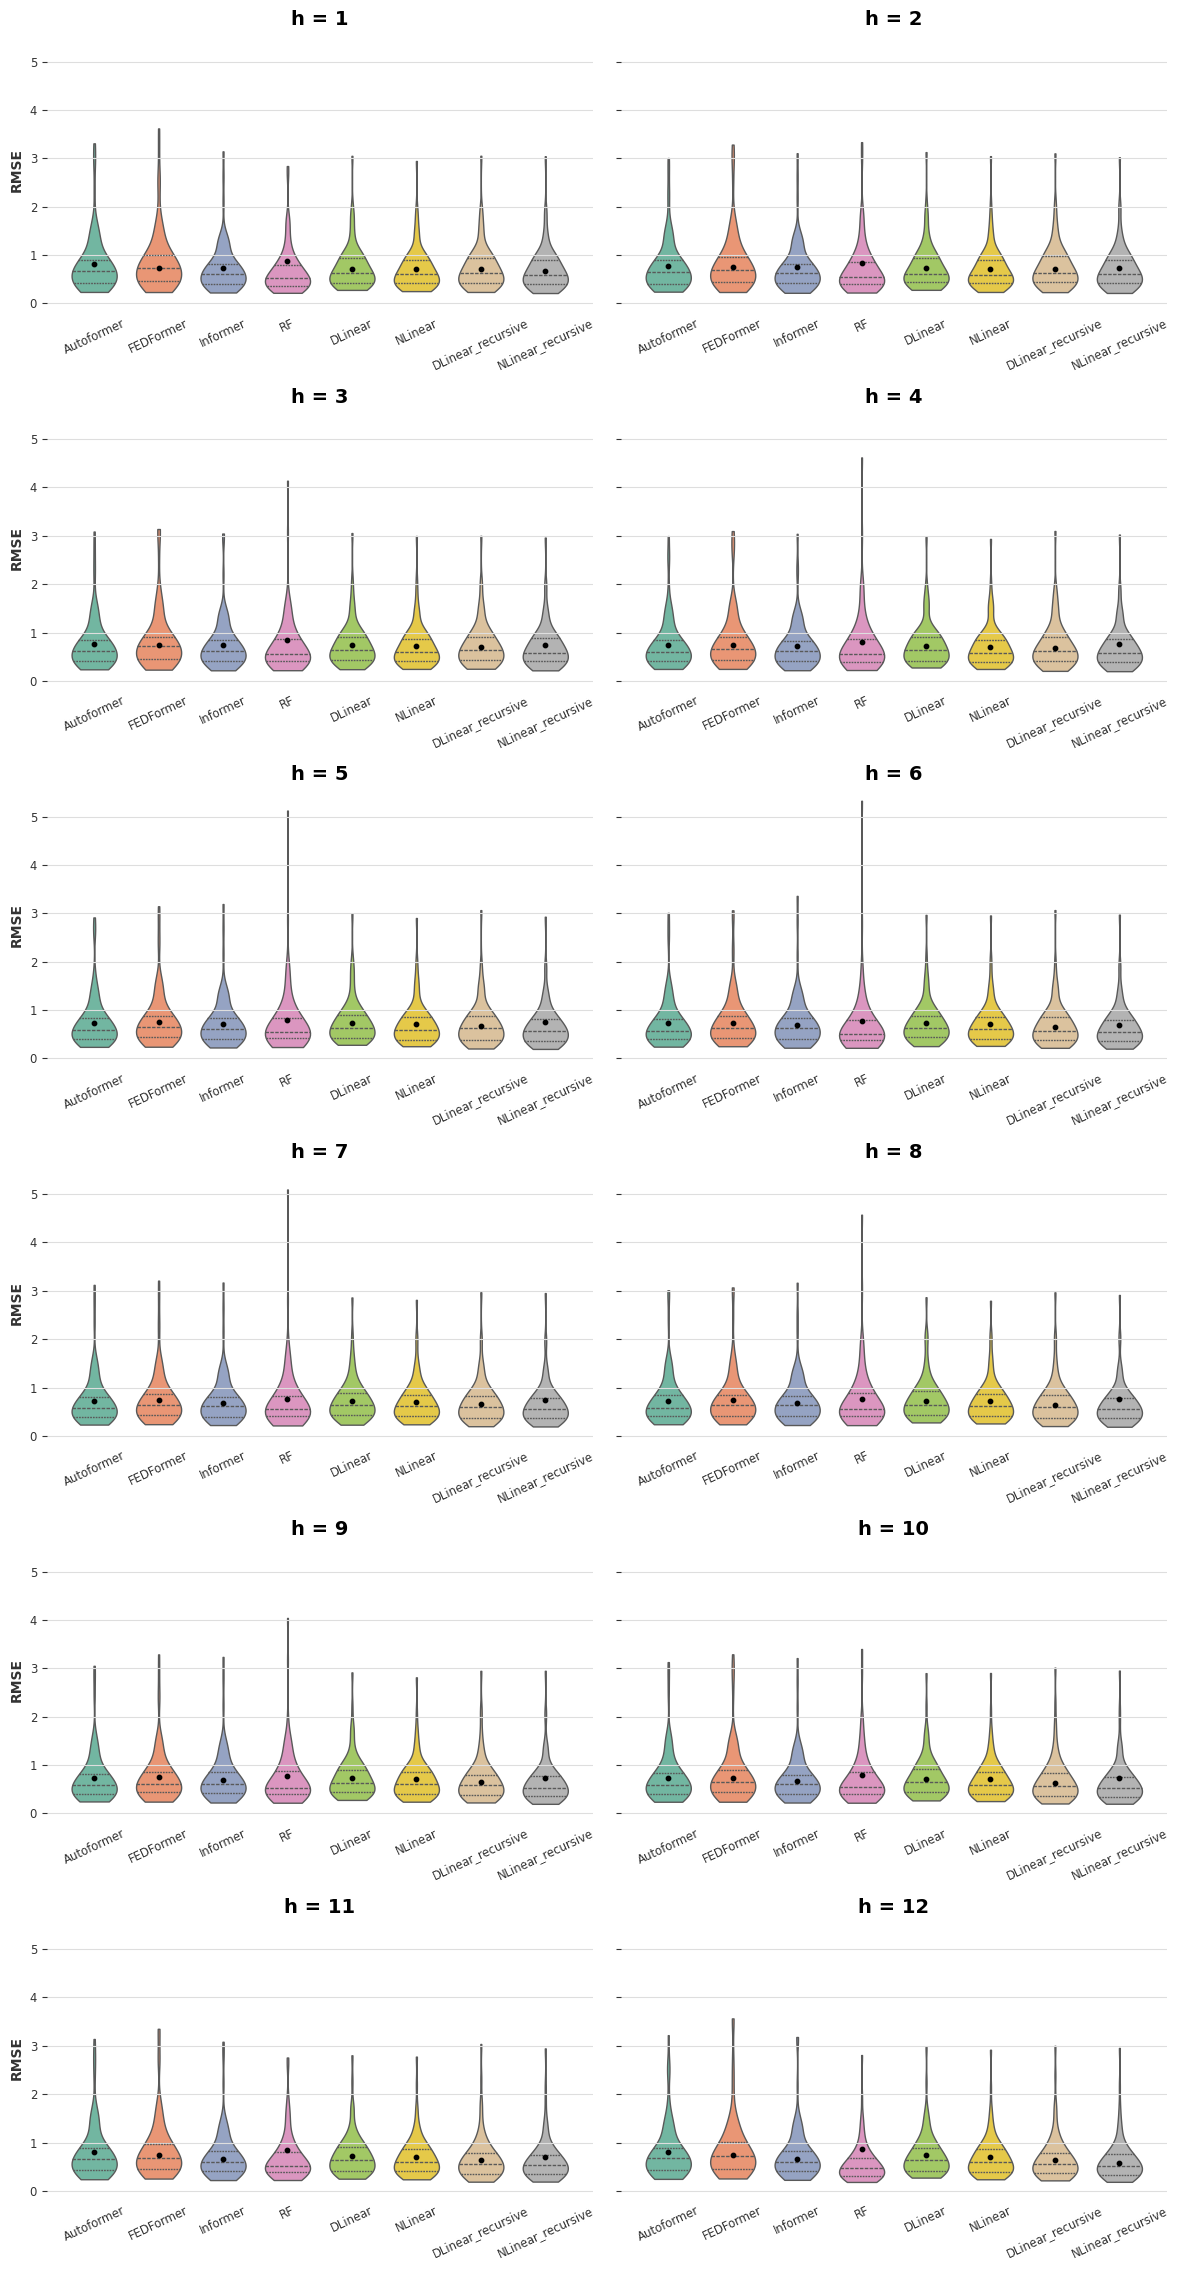

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt


rows = []
for m in models:
    if not ("_h12" in m or m in ["RF", "NLinear_rec", "DLinear_rec"]):  # only keep horizon-12 models + baselines
        continue

    for h, s_rmse in rmse_vals[m].items():
        for country, val in s_rmse.items():
            rows.append({"Model": m.replace("_results", "").replace("_rec", "_recursive").replace("_h12", ""), 
                         "Horizon": h, 
                         "Country": country, 
                         "RMSE": val})

df_rmse = pd.DataFrame(rows)

# Horizons to plot
horizons_to_plot = range(1, 13)

fig, axes = plt.subplots(6, 2, figsize=(12, 24), sharey=True)

for ax, h in zip(axes.flat, horizons_to_plot):
    data_h = df_rmse[df_rmse["Horizon"] == h]
    
    # Violin plot with quartiles + median
    sns.violinplot(
        data=data_h,
        x="Model", y="RMSE", hue="Model", legend=False,
        ax=ax,
        inner="quartile", cut=0,
        width=0.7, linewidth=1,
        palette="Set2"
    )
    
    # Add mean as small black dot
    means = data_h.groupby("Model")["RMSE"].mean()
    ax.scatter(range(len(means)), means,
               color="black", s=10, zorder=3, label="Mean")
    
    ax.set_title(f"h = {h}", fontsize=14, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("RMSE")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("plots/violin_rmse.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\osahl\AppData\Local\Temp\ipykernel_22948\2741539268.py:19: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\osahl\AppData\Local\Temp\ipykernel_22948\2741539268.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
C:\Users\osahl\AppData\Local\Temp\ipykernel_22948\2741539268.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\osahl\AppData\Local\Temp\ipykernel_22948\2741539268.py:19: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplo

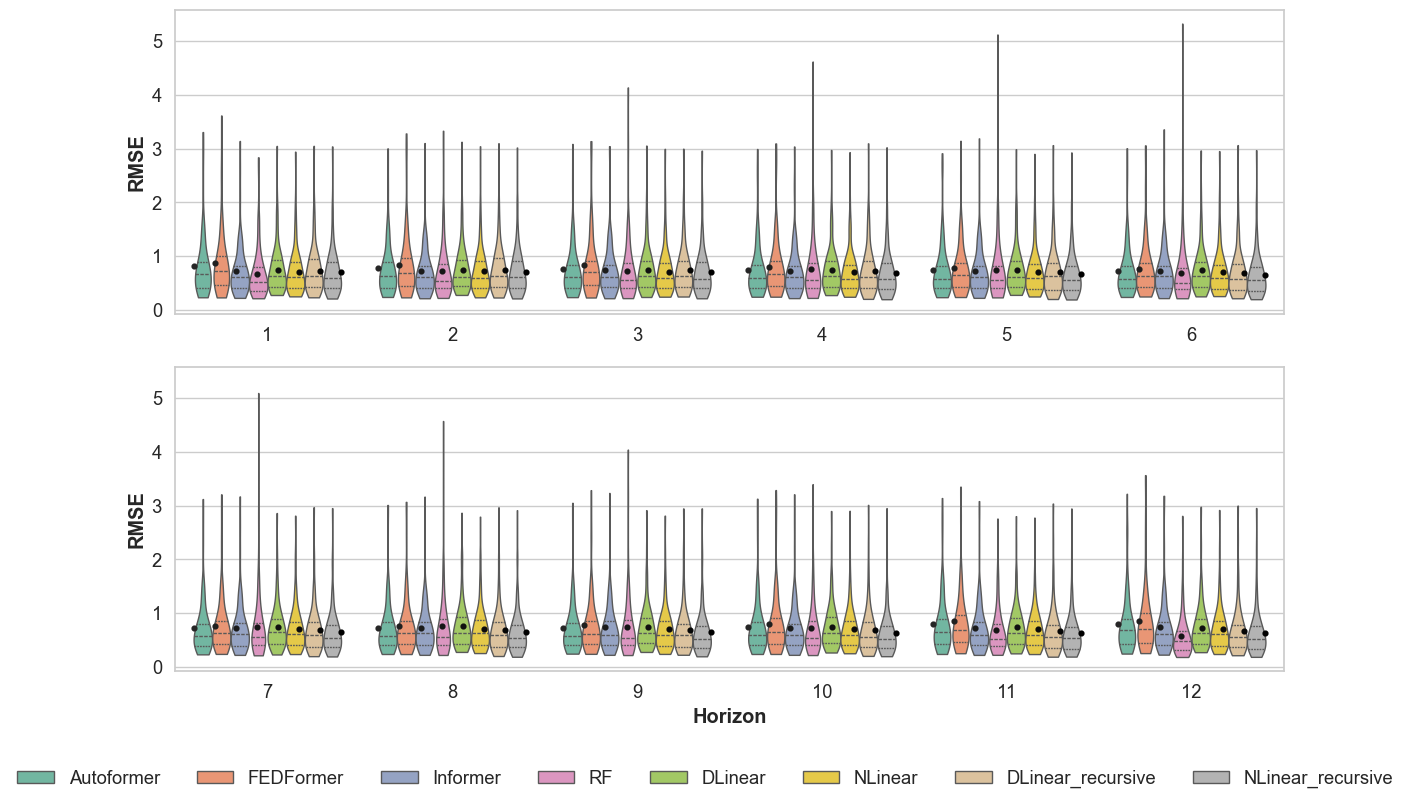

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)

palette = sns.color_palette("Set2", n_colors=df_rmse["Model"].nunique())

def plot_violin_with_means(ax, data, palette):
    # Violin plot
    sns.violinplot(
        data=data,
        x="Horizon", y="RMSE", hue="Model",
        inner="quartile", cut=0, linewidth=1,
        palette=palette, ax=ax
    )
    # Overlay mean with pointplot (aligned automatically with hue groups)
    sns.pointplot(
        data=data,
        x="Horizon", y="RMSE", hue="Model",
        estimator="mean", errorbar=None,
        join=False, dodge=0.8, markers="o",
        color="black", scale=0.6, ax=ax, legend=False
    )

# Top panel (horizons 1–6)
plot_violin_with_means(axes[0], df_rmse[df_rmse["Horizon"] <= 6], palette)
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE")

# Bottom panel (horizons 7–12)
plot_violin_with_means(axes[1], df_rmse[df_rmse["Horizon"] > 6], palette)
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("RMSE")

# Remove duplicate legends
for ax in axes:
    ax.legend_.remove()

# Shared horizontal legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", ncol=len(labels),
           bbox_to_anchor=(0.5, -0.02), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("plots/violin_rmse_means_fixed.pdf", bbox_inches="tight")
plt.show()


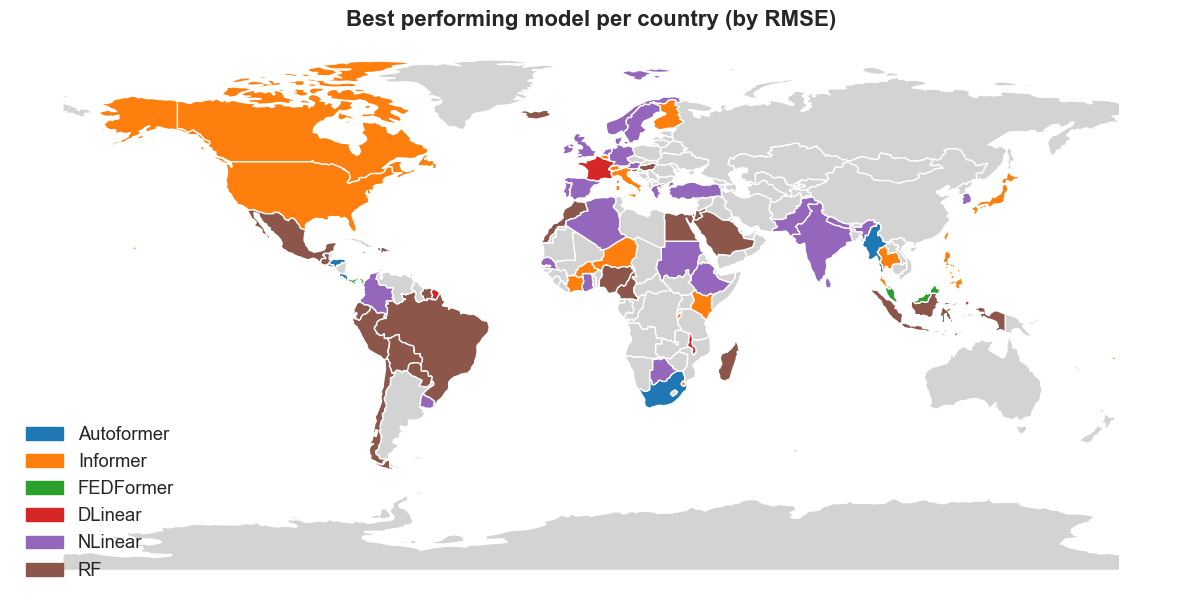

In [ ]:
import geopandas as gpd
import pycountry
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

# --- Step 1: Load shapefile (Natural Earth countries)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# --- Step 2: Compute best model per country
best_model_per_country = {}
for country in true_period.columns:
    best_rmse = float("inf")
    best_model = None
    for m, horizons_dict in rmse_vals.items():
        vals = [s.get(country) for s in horizons_dict.values() if s is not None and country in s.index]
        if len(vals) == 0:
            continue
        avg_rmse = np.mean(vals)
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_model = m.replace("_results", "")
    if best_model is not None:
        best_model_per_country[country] = best_model

best_df = pd.DataFrame(list(best_model_per_country.items()), columns=["country", "best_model"])

country_aliases = {
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Egypt, Arab Rep.": "Egypt",
    "Korea, Rep.": "South Korea",
    "Gambia, The": "Gambia",
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Lucia": "Saint Lucia",
    "Turkey": "Türkiye",        # pycountry uses updated official name
    "Taiwan, China": "Taiwan",  # pycountry recognizes Taiwan
}

def country_to_iso3(name):
    try:
        if name in country_aliases:
            name = country_aliases[name]
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None


    
def simplify_model(name):
    return (str(name)
            .replace("_h12", "")
            .replace("_h6", "")
            .replace("_h1", "")
            .replace("_results", ""))

best_df["best_model_simple"] = best_df["best_model"].apply(simplify_model)
best_df["iso3"] = best_df["country"].apply(country_to_iso3)

# --- Step 4: Colors
model_colors = {
    "Autoformer": "#1f77b4",   # blue
    "Informer": "#ff7f0e",     # orange
    "FEDFormer": "#2ca02c",    # green
    "DLinear": "#d62728",      # red
    "NLinear": "#9467bd",      # purple
    "RF": "#8c564b",           # brown
}

# --- Step 5: Merge with world map
world = world.merge(best_df, left_on="ADM0_A3", right_on="iso3", how="left")
# Colors per country
colors = world["best_model_simple"].map(model_colors).fillna("lightgrey")

fig, ax = plt.subplots(figsize=(15, 8))
world.plot(ax=ax, color=colors)

# Custom legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=m) for m, c in model_colors.items()]
ax.legend(handles=patches, loc="lower left", frameon=False)

ax.set_title("Best performing model per country (by RMSE)", fontsize=16, weight="bold")
ax.axis("off")
plt.show()



In [ ]:
# Frequency table (already computed)
freq_table = (
    best_df["best_model_simple"]
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Num_countries")
)
freq_table["Share"] = (freq_table["Num_countries"] / freq_table["Num_countries"].sum()).round(2)

# Format Share as %
freq_table["Share"] = freq_table["Share"].apply(lambda x: f"{int(x*100)}%")

# Sort by number of countries
freq_table = freq_table.sort_values("Num_countries", ascending=False).reset_index(drop=True)

# Display
import pandas as pd
pd.set_option("display.colheader_justify", "center")
print(freq_table.to_string(index=False))


  Model     Num_countries Share
   NLinear       30        33% 
        RF       30        33% 
  Informer       21        23% 
Autoformer        5         5% 
   DLinear        3         3% 
 FEDFormer        2         2% 


In [ ]:
import pandas as pd
import numpy as np

# --- Build summary table of best models per horizon ---
summary_rows = []

for h in range(1, 13):
    best_model_per_country = {}
    for country in true_period.columns:
        best_rmse, best_model = float("inf"), None
        for m, horizons_dict in rmse_vals.items():
            s = horizons_dict.get(h)
            if s is not None and country in s.index:
                val = s[country]
                if val < best_rmse:
                    best_rmse, best_model = val, m.replace("_results", "")
        if best_model is not None:
            best_model_per_country[country] = simplify_model(best_model)

    # counts per model at this horizon
    counts = pd.Series(best_model_per_country).value_counts()
    total = counts.sum()
    for model, count in counts.items():
        summary_rows.append({
            "Horizon": h,
            "Model": model,
            "Count": count,
            "Share": round(count / total, 3) if total > 0 else np.nan
        })

# --- Make DataFrame ---
summary_df = pd.DataFrame(summary_rows)

# Pivot for readability: models as rows, horizons as columns
summary_pivot = summary_df.pivot(index="Model", columns="Horizon", values="Count").fillna(0).astype(int)

# Add totals across horizons
summary_pivot["Total"] = summary_pivot.sum(axis=1)

# Show the table
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", None)
print(summary_pivot)

# Optional: export to LaTeX for thesis
print(summary_pivot.to_latex())


Horizon      1   2   3   4   5   6   7   8   9  10  11  12  Total
Model                                                            
Autoformer   5   7  10   9   7  13  14  13  16  11   8   3   116 
DLinear      3   5   7   3   2   2   6   3   2   2   3   0    38 
FEDFormer    2   1   2   1   5   3   6   6   3   1   3   0    33 
Informer    10  16  19  23  19  16  20  10  12  20  18   4   187 
NLinear     28  25  22  27  30  19  19  28  29  28  24   3   282 
RF          43  37  31  28  28  38  26  31  29  29  35  80   435 
RW           0   0   0   0   0   0   0   0   0   0   0   1     1 
\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Horizon & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & Total \\
Model &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
Autoformer & 5 & 7 & 10 & 9 & 7 & 13 & 14 & 13 & 16 & 11 & 8 & 3 & 116 \\
DLinear & 3 & 5 & 7 & 3 & 2 & 2 & 6 & 3 & 2 & 2 & 3 & 0 & 38 \\
FEDFormer & 2 & 1 & 2 & 1 & 5 & 3 & 6 & 6 & 3 & 1 & 3 & 0 & 33 \\
Informer & 10 & 16 & 19 & 23 & 19 

In [ ]:
for h in range(1, 13):
    counts = {m: len(rmse_vals[m].get(h, [])) for m in rmse_vals}
    print(f"h={h}", counts)


h=1 {'Autoformer_h1_results': 91, 'Autoformer_h6_results': 91, 'Autoformer_h12_results': 91, 'FEDFormer_h1_results': 91, 'FEDFormer_h6_results': 91, 'FEDFormer_h12_results': 91, 'Informer_h1_results': 91, 'Informer_h6_results': 91, 'Informer_h12_results': 91, 'DLinear_h1': 91, 'DLinear_h6': 91, 'DLinear_h12': 91, 'NLinear_h1': 91, 'NLinear_h6': 91, 'NLinear_h12': 91, 'RW': 90, 'RF': 90}
h=2 {'Autoformer_h1_results': 0, 'Autoformer_h6_results': 91, 'Autoformer_h12_results': 91, 'FEDFormer_h1_results': 0, 'FEDFormer_h6_results': 91, 'FEDFormer_h12_results': 91, 'Informer_h1_results': 0, 'Informer_h6_results': 91, 'Informer_h12_results': 91, 'DLinear_h1': 0, 'DLinear_h6': 91, 'DLinear_h12': 91, 'NLinear_h1': 0, 'NLinear_h6': 91, 'NLinear_h12': 91, 'RW': 90, 'RF': 90}
h=3 {'Autoformer_h1_results': 0, 'Autoformer_h6_results': 91, 'Autoformer_h12_results': 91, 'FEDFormer_h1_results': 0, 'FEDFormer_h6_results': 91, 'FEDFormer_h12_results': 91, 'Informer_h1_results': 0, 'Informer_h6_results': 

In [ ]:
for h in range(1, 13):
    available = [m for m, horizons in rmse_vals.items() if horizons.get(h) is not None]
    print(f"h={h}: {len(available)} models available -> {available}")

h=1: 17 models available -> ['Autoformer_h1_results', 'Autoformer_h6_results', 'Autoformer_h12_results', 'FEDFormer_h1_results', 'FEDFormer_h6_results', 'FEDFormer_h12_results', 'Informer_h1_results', 'Informer_h6_results', 'Informer_h12_results', 'DLinear_h1', 'DLinear_h6', 'DLinear_h12', 'NLinear_h1', 'NLinear_h6', 'NLinear_h12', 'RW', 'RF']
h=2: 12 models available -> ['Autoformer_h6_results', 'Autoformer_h12_results', 'FEDFormer_h6_results', 'FEDFormer_h12_results', 'Informer_h6_results', 'Informer_h12_results', 'DLinear_h6', 'DLinear_h12', 'NLinear_h6', 'NLinear_h12', 'RW', 'RF']
h=3: 12 models available -> ['Autoformer_h6_results', 'Autoformer_h12_results', 'FEDFormer_h6_results', 'FEDFormer_h12_results', 'Informer_h6_results', 'Informer_h12_results', 'DLinear_h6', 'DLinear_h12', 'NLinear_h6', 'NLinear_h12', 'RW', 'RF']
h=4: 12 models available -> ['Autoformer_h6_results', 'Autoformer_h12_results', 'FEDFormer_h6_results', 'FEDFormer_h12_results', 'Informer_h6_results', 'Informer_

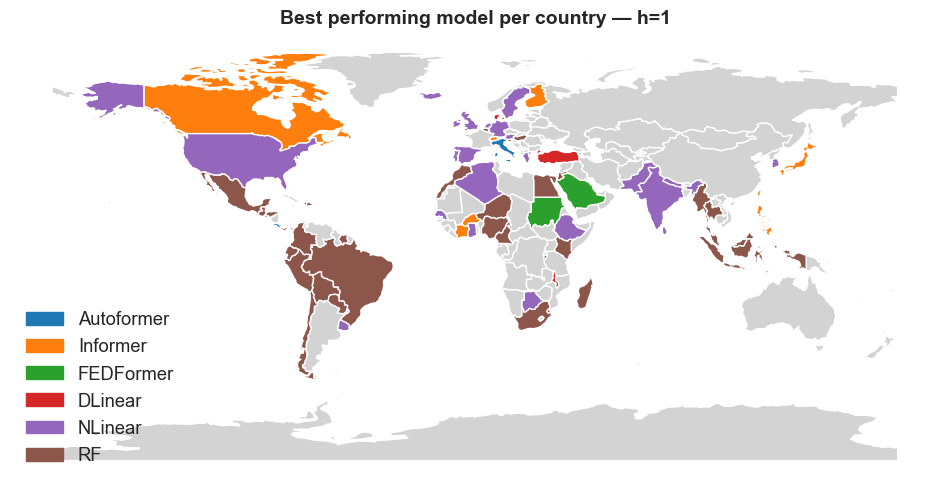

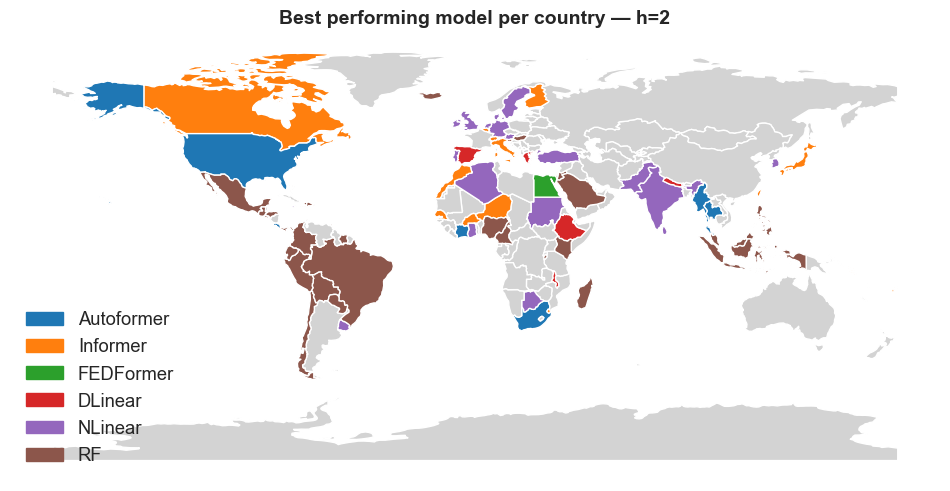

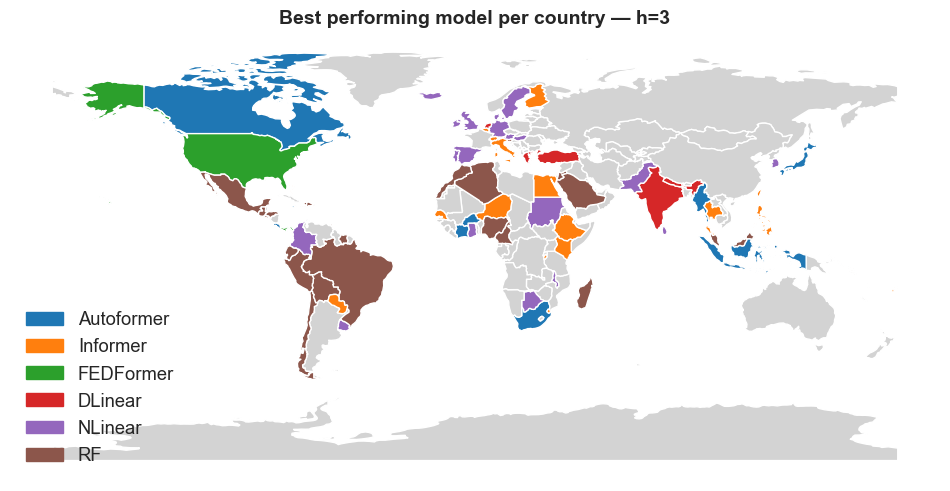

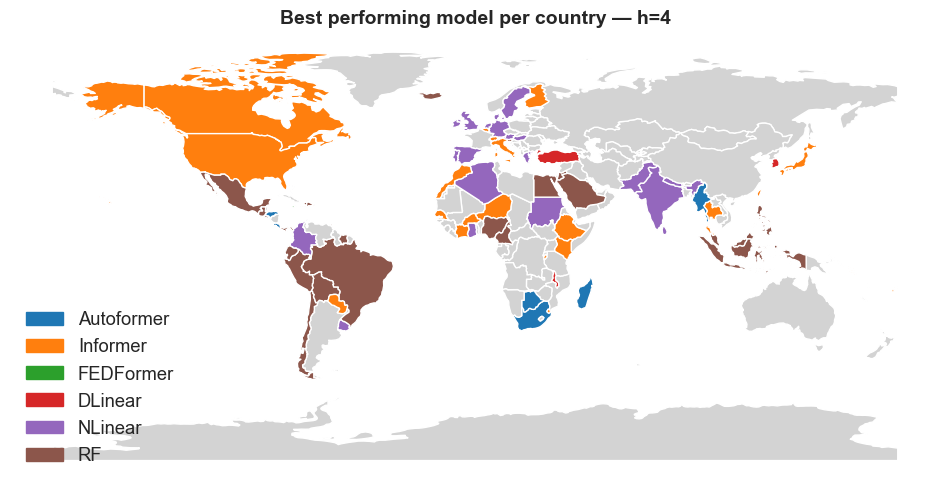

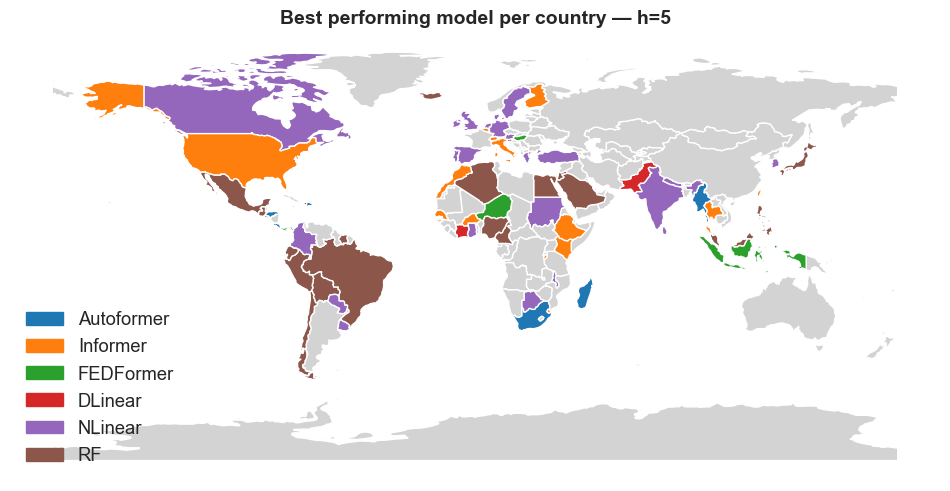

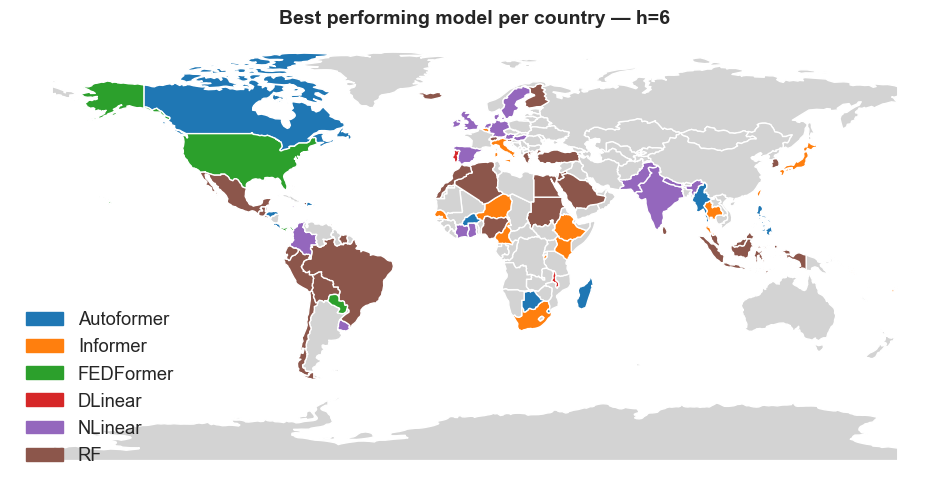

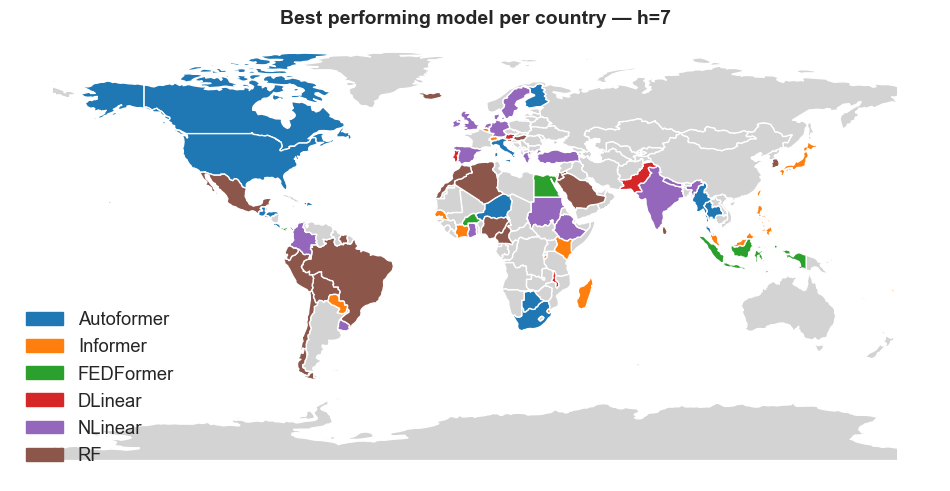

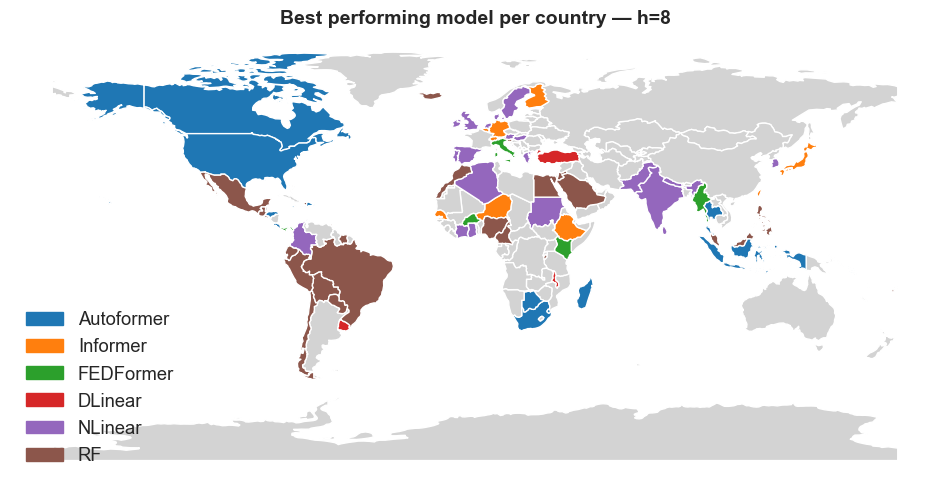

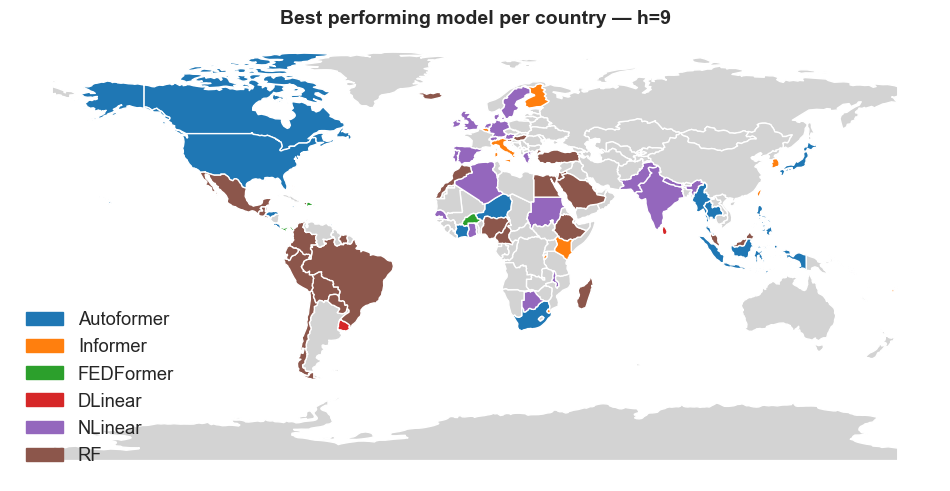

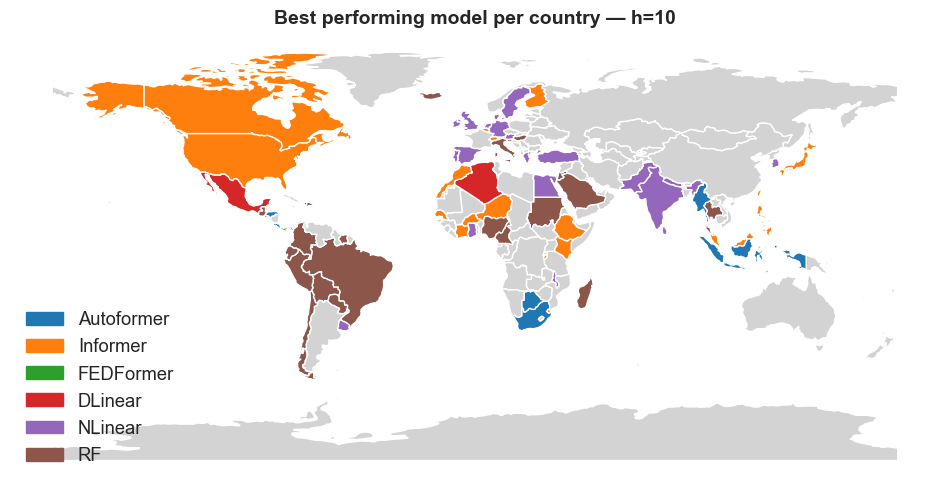

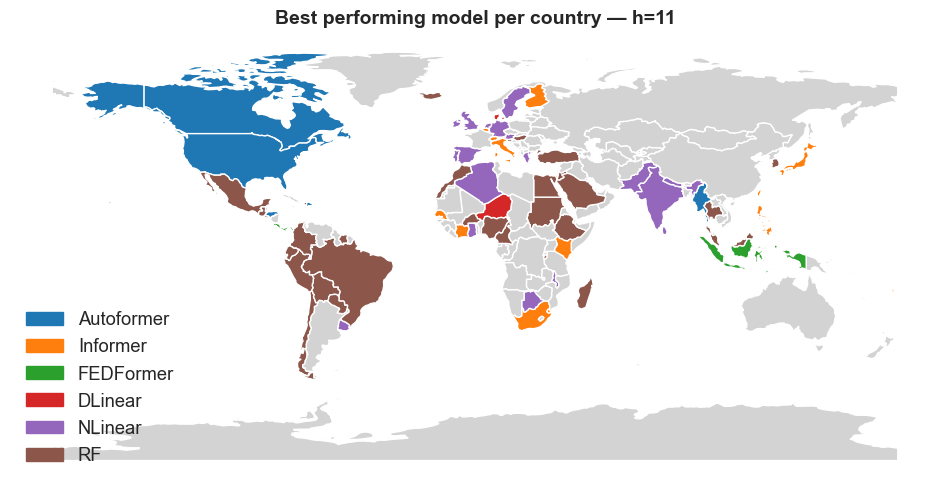

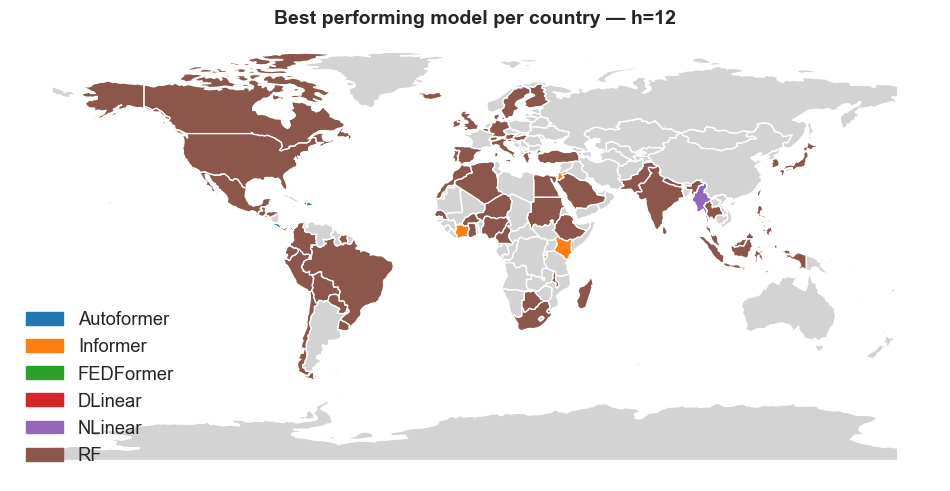

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# --- Read base world map (keep a clean copy for merging each time) ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world_base = gpd.read_file(url)

# --- Build best model per country per horizon ---
maps = {}
for h in range(1, 13):
    best_model_per_country = {}
    for country in true_period.columns:
        best_rmse, best_model = float("inf"), None
        for m, horizons_dict in rmse_vals.items():
            s = horizons_dict.get(h)
            if s is not None and country in s.index:
                val = s[country]
                if val < best_rmse:
                    best_rmse, best_model = val, m.replace("_results", "")
        if best_model is not None:
            best_model_per_country[country] = best_model

    df = pd.DataFrame(list(best_model_per_country.items()), columns=["country", "best_model"])
    df["best_model_simple"] = df["best_model"].apply(simplify_model)
    df["iso3"] = df["country"].apply(country_to_iso3)
    maps[h] = df

# --- Plot one map per horizon ---
for h in range(1, 13):
    df = maps[h]
    world_h = world_base.merge(df, left_on="ISO_A3", right_on="iso3", how="left")

    colors = world_h["best_model_simple"].map(model_colors).fillna("lightgrey")

    fig, ax = plt.subplots(figsize=(12, 6))
    world_h.plot(ax=ax, color=colors)

    # Legend
    patches = [mpatches.Patch(color=c, label=m) for m, c in model_colors.items()]
    ax.legend(handles=patches, loc="lower left", frameon=False)

    ax.set_title(f"Best performing model per country — h={h}", fontsize=14, weight="bold")
    ax.axis("off")
    plt.show()


In [ ]:
missing_iso = best_df[best_df["iso3"].isna()]
print("Countries with missing ISO mapping:\n", missing_iso["country"].unique())


Countries with missing ISO mapping:
 []
